### Query Structuring

进入数据库后，如何处理包含特定条件的提问  
例如，如果用户问：“找一段 2024 年以后发布的关于 LangChain 的视频”，传统的语义搜索往往会忽略“2024 年以后”这个硬性条件，或者只是把它当成普通文本处理，导致结果不精准 

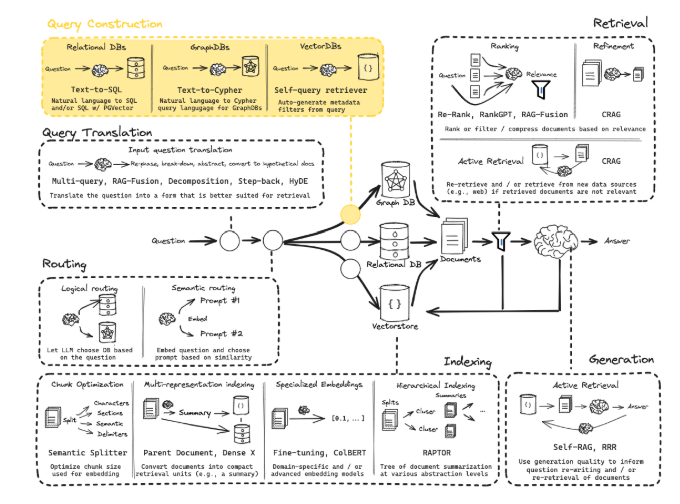

#### 一、核心动机：解决语义搜索的局限性
向量数据库除了存储文本向量，通常还能存储元数据。如发布日期、作者、观看次数等
- 问题：单纯的语义搜索擅长找内容相似的东西，但不擅长处理大于、小于或等于的结构化过滤
- 方案：查询结构化。将用户的自然语言转换为数据库可以理解的领域特定语言（DSL），也就额是元数据过滤器
  

#### 二、工作原理：利用函数调用
- 定义：定义数据库中有哪些元数据字段
- 绑定模型：将这个定义的结构作为函数活工具绑定到LLM上
- 解析提问：LLM接受问题，提取语义搜索的关键词，并识别过滤条件
- 生成结构化对象：输出一个干净的Json或pydantic对象，供检索器直接使用

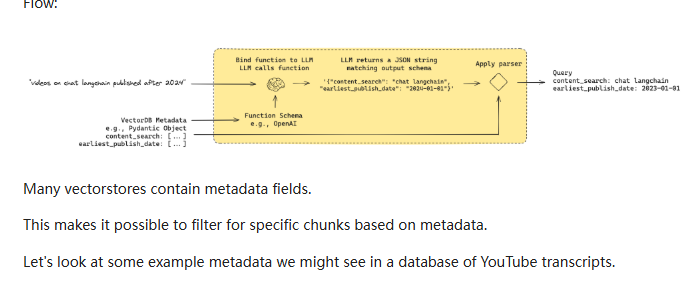

In [ ]:

from langchain_community.document_loaders import YoutubeLoader
from yt_dlp import YoutubeDL

# 获取元数据
url = "https://www.youtube.com/watch?v=pbAd8O1Lvm4"
ydl_opts = {"quiet": True, "skip_download": True}
with YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(url, download=False)
    metadata = {
        "title": info.get("title"),
        "author": info.get("uploader"),
        "length": info.get("duration"),
        "view_count": info.get("view_count"),
        "description": info.get("description"),
        "publish_date": info.get("upload_date"),
    }

# 获取字幕
loader = YoutubeLoader.from_youtube_url(url, add_video_info=False)
docs = loader.load()
if docs:
    docs[0].metadata.update(metadata)  # 合并元数据
    print(docs[0].metadata)

{'source': 'pbAd8O1Lvm4', 'title': 'Self-reflective RAG with LangGraph: Self-RAG and CRAG', 'author': 'LangChain', 'length': 1058, 'view_count': 37375, 'description': 'Self-reflection can greatly enhance RAG, enabling correction of poor quality retrieval or generations. Several recent RAG papers focus on this theme, but implementing the ideas can be tricky. Here, we show that LangGraph can be easily used for "flow engineering" of self-reflective RAG pipelines. We provide cookbooks for implementing ideas from two interesting papers, Self-RAG and C-RAG.\n\nCode:\nhttps://github.com/langchain-ai/langgraph/tree/main/examples/rag', 'publish_date': '20240207'}


We can define a schema for structured search queries

In [ ]:
import datetime
from typing import Literal, Optional, Tuple
from pydantic import BaseModel, Field

class TutorialSearch(BaseModel):
    """Search over a database of tutorial videos about a software library."""

    content_search: str = Field(
        ...,
        description="Similarity search query applied to video transcripts.",
    )
    title_search: str = Field(
        ...,
        description=(
            "Alternate version of the content search query to apply to video titles. "
            "Should be succinct and only include key words that could be in a video "
            "title."
        ),
    )
    min_view_count: Optional[int] = Field(
        None,
        description="Minimum view count filter, inclusive. Only use if explicitly specified.",
    )
    max_view_count: Optional[int] = Field(
        None,
        description="Maximum view count filter, exclusive. Only use if explicitly specified.",
    )
    earliest_publish_date: Optional[datetime.date] = Field(
        None,
        description="Earliest publish date filter, inclusive. Only use if explicitly specified.",
    )
    latest_publish_date: Optional[datetime.date] = Field(
        None,
        description="Latest publish date filter, exclusive. Only use if explicitly specified.",
    )
    min_length_sec: Optional[int] = Field(
        None,
        description="Minimum video length in seconds, inclusive. Only use if explicitly specified.",
    )
    max_length_sec: Optional[int] = Field(
        None,
        description="Maximum video length in seconds, exclusive. Only use if explicitly specified.",
    )

    def pretty_print(self) -> None:
        for field in self.__fields__:
            if getattr(self, field) is not None and getattr(self, field) != getattr(
                self.__fields__[field], "default", None
            ):
                print(f"{field}: {getattr(self, field)}")

In [15]:
import os
from langchain_community.chat_models.tongyi import ChatTongyi

# 设置 API Key
DASHSCOPE_API_KEY = "sk-bb5a3bc665be4d35bea3efce0196c8c1"
os.environ["DASHSCOPE_API_KEY"] = DASHSCOPE_API_KEY

# 模型配置
LLM_MODEL = "qwen-turbo"
TEMPERATURE = 0.0

# 初始化通义千问模型
llm = ChatTongyi(
    model=LLM_MODEL,
    temperature=TEMPERATURE,
    dashscope_api_key=DASHSCOPE_API_KEY
)

In [16]:
from langchain_core.prompts import ChatPromptTemplate


system = """You are an expert at converting user questions into database queries. \
You have access to a database of tutorial videos about a software library for building LLM-powered applications. \
Given a question, return a database query optimized to retrieve the most relevant results.

If there are acronyms or words you are not familiar with, do not try to rephrase them."""
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

structured_llm = llm.with_structured_output(TutorialSearch)
query_analyzer = prompt | structured_llm
query_analyzer.invoke({"question": "rag from scratch"}).pretty_print()

content_search: rag from scratch
title_search: rag from scratch


C:\Users\23017\AppData\Local\Temp\ipykernel_40820\3806102375.py:46: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  for field in self.__fields__:
C:\Users\23017\AppData\Local\Temp\ipykernel_40820\3806102375.py:48: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  self.__fields__[field], "default", None


In [17]:
query_analyzer.invoke(
    {"question": "videos on chat langchain published in 2023"}
).pretty_print()

content_search: chat langchain
title_search: chat langchain
earliest_publish_date: 2023-01-01
latest_publish_date: 2023-12-31


C:\Users\23017\AppData\Local\Temp\ipykernel_40820\3806102375.py:46: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  for field in self.__fields__:
C:\Users\23017\AppData\Local\Temp\ipykernel_40820\3806102375.py:48: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  self.__fields__[field], "default", None


In [18]:
query_analyzer.invoke(
    {"question": "videos that are focused on the topic of chat langchain that are published before 2024"}
).pretty_print()

content_search: chat langchain
title_search: chat langchain
latest_publish_date: 2024-01-01


C:\Users\23017\AppData\Local\Temp\ipykernel_40820\3806102375.py:46: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  for field in self.__fields__:
C:\Users\23017\AppData\Local\Temp\ipykernel_40820\3806102375.py:48: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  self.__fields__[field], "default", None


In [20]:
query_analyzer.invoke(
    {
        "question": "how to use multi-modal models in an agent, only videos under 5 minutes"
    }
).pretty_print()

content_search: how to use multi-modal models in an agent
title_search: multi-modal models agent
max_length_sec: 300


C:\Users\23017\AppData\Local\Temp\ipykernel_40820\3806102375.py:46: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  for field in self.__fields__:
C:\Users\23017\AppData\Local\Temp\ipykernel_40820\3806102375.py:48: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  self.__fields__[field], "default", None
